**Nama:** Nazly Rafa Oktafian Nuzqu  
**Dataset:** Heart Disease Dataset (Kaggle)  
**Link:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

# **1. Perkenalan Dataset**

Dataset yang digunakan adalah **Heart Disease Dataset** yang bersumber dari Kaggle.

Dataset ini berisi 303 sampel pasien dengan 13 fitur medis seperti usia, jenis kelamin, jenis nyeri dada, tekanan darah, kolesterol, dan lain-lain. Kolom target `target` bernilai:
- **1** = pasien memiliki penyakit jantung
- **0** = pasien tidak memiliki penyakit jantung

Tujuan proyek ini adalah membangun model klasifikasi biner untuk memprediksi apakah seorang pasien berisiko terkena penyakit jantung berdasarkan data medisnya.

**Sumber:** https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

# **2. Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import warnings
warnings.filterwarnings('ignore')

# **3. Memuat Dataset**

In [2]:
df = pd.read_csv('heart.csv')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [5]:
df.shape

(1025, 14)

# **4. Exploratory Data Analysis (EDA)**

In [6]:
# Cek Missing Values 
print('=== Missing Values ===')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== Missing Values ===
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Total missing values: 0


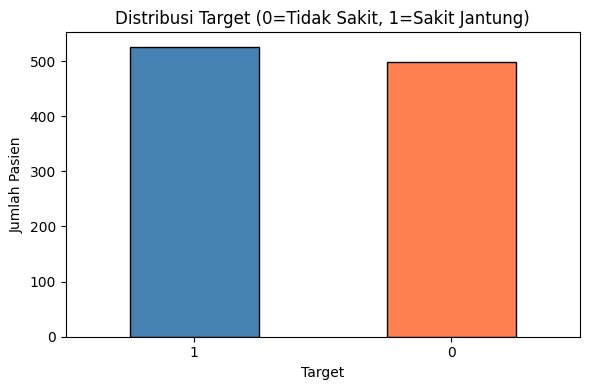

target
1    526
0    499
Name: count, dtype: int64


In [7]:
# Distribusi Target 
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Distribusi Target (0=Tidak Sakit, 1=Sakit Jantung)')
plt.xlabel('Target')
plt.ylabel('Jumlah Pasien')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(df['target'].value_counts())

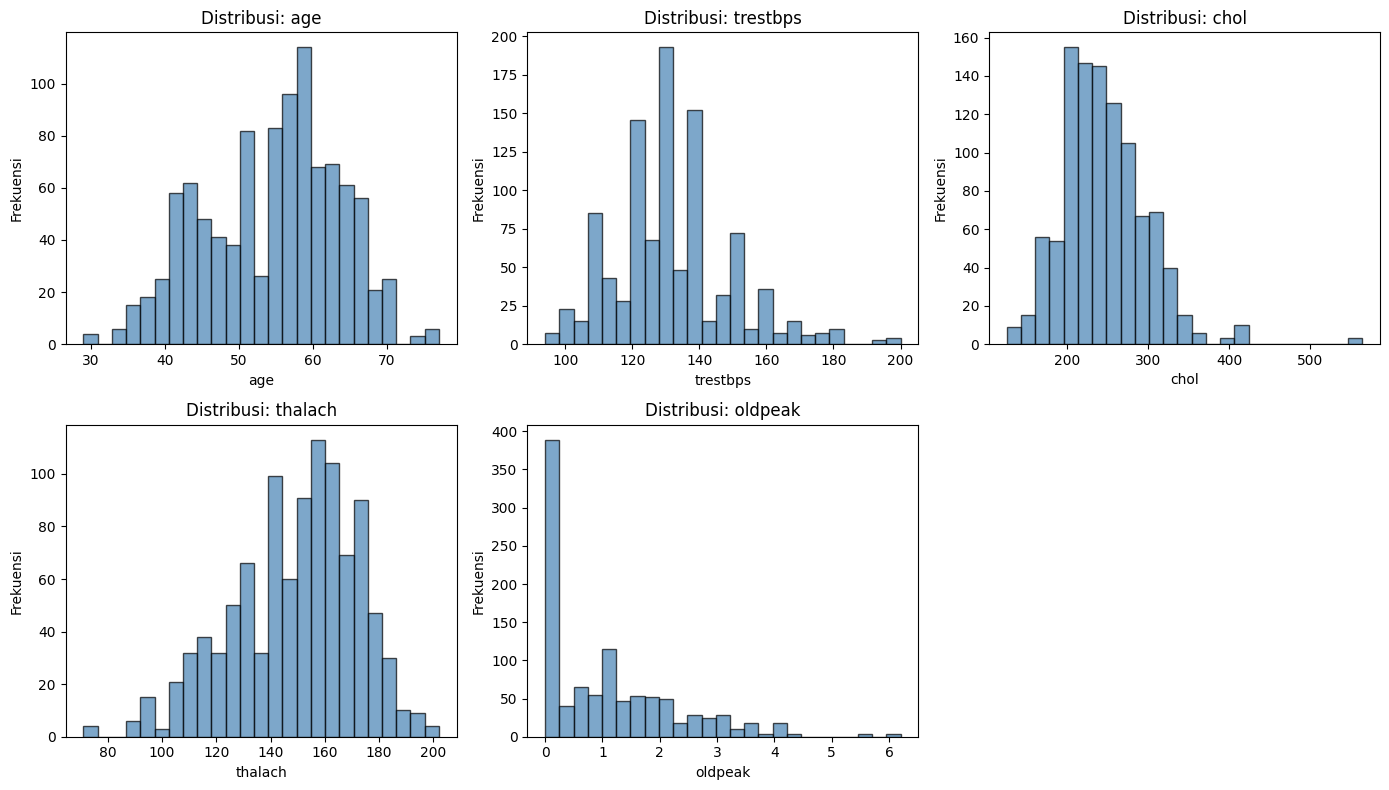

In [8]:
# Distribusi Fitur Numerik
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi: {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')
axes[-1].axis('off')
plt.tight_layout()
plt.show()

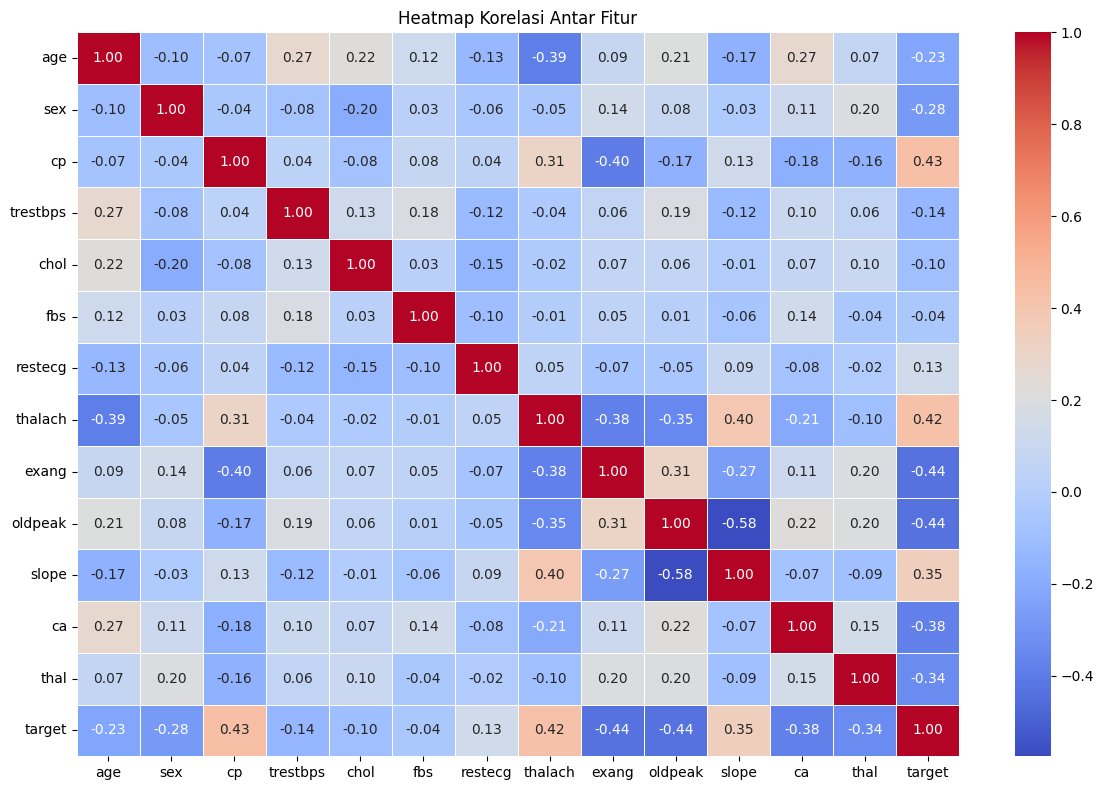

In [9]:
#  Heatmap Korelasi 
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

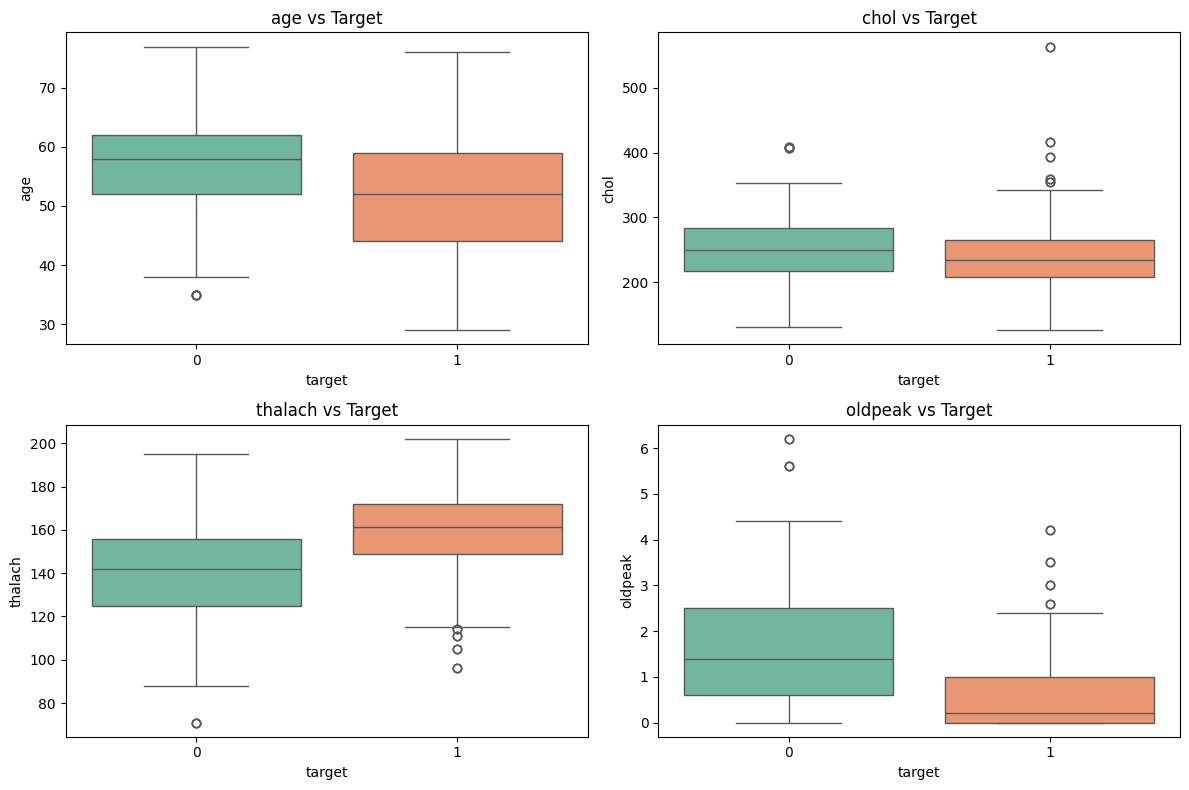

In [10]:
#  Boxplot Fitur Penting vs Target 
features_to_plot = ['age', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, feat in enumerate(features_to_plot):
    sns.boxplot(x='target', y=feat, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'{feat} vs Target')
plt.tight_layout()
plt.show()

In [11]:
# Cek Duplikasi 
print(f'Jumlah duplikat: {df.duplicated().sum()}')

Jumlah duplikat: 723


# **5. Data Preprocessing**

In [12]:
# Hapus Duplikat
df_clean = df.drop_duplicates().reset_index(drop=True)
print(f'Shape setelah hapus duplikat: {df_clean.shape}')

Shape setelah hapus duplikat: (302, 14)


In [13]:
# Pisahkan Fitur dan Target 
X = df_clean.drop(columns=['target'])
y = df_clean['target']
print('Shape X:', X.shape)
print('Shape y:', y.shape)
print('Distribusi target:\n', y.value_counts())

Shape X: (302, 13)
Shape y: (302,)
Distribusi target:
 target
1    164
0    138
Name: count, dtype: int64


In [14]:
# Deteksi dan Hapus Outlier dengan IsolationForest 
iso = IsolationForest(contamination=0.05, random_state=42)
outlier_labels = iso.fit_predict(X)
mask = outlier_labels == 1
X_clean = X[mask].reset_index(drop=True)
y_clean = y[mask].reset_index(drop=True)
print(f'Data sebelum hapus outlier: {X.shape[0]}')
print(f'Data setelah hapus outlier : {X_clean.shape[0]}')
print(f'Outlier dihapus            : {X.shape[0] - X_clean.shape[0]}')

Data sebelum hapus outlier: 302
Data setelah hapus outlier : 286
Outlier dihapus            : 16


In [15]:
# Split Train/Test 
X_train, X_test, y_train, y_test = train_test_split(
    X_clean, y_clean, test_size=0.2, random_state=42, stratify=y_clean
)
print(f'Train size: {X_train.shape[0]}')
print(f'Test size : {X_test.shape[0]}')

Train size: 228
Test size : 58


In [16]:
# Standarisasi Fitur 
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled  = pd.DataFrame(scaler.transform(X_test), columns=X.columns)
print('Standarisasi selesai!')
print('Mean fitur (train, setelah scaling):', X_train_scaled.mean().round(4).values)

Standarisasi selesai!
Mean fitur (train, setelah scaling): [-0.  0.  0.  0.  0.  0.  0.  0. -0.  0. -0. -0.  0.]


In [17]:
# Save Dataset-
train_df = X_train_scaled.copy()
train_df['target'] = y_train.values
test_df = X_test_scaled.copy()
test_df['target'] = y_test.values

train_df.to_csv('heart_train_preprocessed.csv', index=False)
test_df.to_csv('heart_test_preprocessed.csv', index=False)

print('Dataset preprocessed berhasil disimpan!')
print('File: heart_train_preprocessed.csv')
print('File: heart_test_preprocessed.csv')

Dataset preprocessed berhasil disimpan!
File: heart_train_preprocessed.csv
File: heart_test_preprocessed.csv
